# RenalScan — 01: Data Exploration & Bounding Box Alignment

This notebook performs initial Exploratory Data Analysis (EDA) on the RenalScan CT dataset:
1. **Dataset Split Summary**: Counts images and YOLO label files across train, validation, and test splits.
2. **Data Configuration & Metadata**: Reads `data.yaml` class names and inspects CT image resolutions.
3. **Bounding Box Visualization**: Converts normalized YOLO bounding box coordinates $(x_c, y_c, w, h)$ into pixel coordinates and overlays bounding box annotations on 6 sample CT images to verify coordinate alignment.

In [1]:
import os
from pathlib import Path
import cv2
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define dataset paths relative to notebook location
DATA_DIR = Path("../data")
TRAIN_IMG_DIR = DATA_DIR / "train" / "images"
TRAIN_LBL_DIR = DATA_DIR / "train" / "labels"
VALID_IMG_DIR = DATA_DIR / "valid" / "images"
VALID_LBL_DIR = DATA_DIR / "valid" / "labels"
TEST_IMG_DIR = DATA_DIR / "test" / "images"
TEST_LBL_DIR = DATA_DIR / "test" / "labels"
YAML_PATH = DATA_DIR / "data.yaml"

print(f"Data Directory Exists: {DATA_DIR.exists()}")

Data Directory Exists: True


In [2]:
# 1. Count images and labels per split
def count_split_files(img_dir, lbl_dir):
    images = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png")) + list(img_dir.glob("*.jpeg"))
    labels = list(lbl_dir.glob("*.txt"))
    return len(images), len(labels)

train_imgs, train_lbls = count_split_files(TRAIN_IMG_DIR, TRAIN_LBL_DIR)
valid_imgs, valid_lbls = count_split_files(VALID_IMG_DIR, VALID_LBL_DIR)
test_imgs, test_lbls = count_split_files(TEST_IMG_DIR, TEST_LBL_DIR)

split_df = pd.DataFrame({
    'Dataset Split': ['Train', 'Validation', 'Test', 'Total'],
    'Image Count': [train_imgs, valid_imgs, test_imgs, train_imgs + valid_imgs + test_imgs],
    'Label File Count': [train_lbls, valid_lbls, test_lbls, train_lbls + valid_lbls + test_lbls]
})

print("=== RENALSCAN DATASET SPLIT SUMMARY ===")
print(split_df.to_string(index=False))

=== RENALSCAN DATASET SPLIT SUMMARY ===
Dataset Split  Image Count  Label File Count
        Train         1054              1054
   Validation          123               123
         Test          123               123
        Total         1300              1300


In [3]:
# 2. Inspect data.yaml and image resolutions
with open(YAML_PATH, 'r') as f:
    data_config = yaml.safe_load(f)

print("=== DATA CONFIGURATION (data.yaml) ===")
print(f"Number of Classes (nc): {data_config.get('nc')}")
print(f"Class Names: {data_config.get('names')}")

sample_imgs = list(TRAIN_IMG_DIR.glob("*.jpg"))[:5]
print("\n=== SAMPLE IMAGE RESOLUTIONS ===")
for img_p in sample_imgs:
    img = cv2.imread(str(img_p))
    if img is not None:
        h, w, c = img.shape
        print(f"Image: {img_p.name[:35]}... | Dimensions: {w}x{h} px | Channels: {c}")

=== DATA CONFIGURATION (data.yaml) ===
Number of Classes (nc): 1
Class Names: ['Kidney Stone']

=== SAMPLE IMAGE RESOLUTIONS ===
Image: 1-3-46-670589-33-1-6370070074986551... | Dimensions: 391x320 px | Channels: 3
Image: 1-3-46-670589-33-1-6370070074986551... | Dimensions: 391x320 px | Channels: 3
Image: 1-3-46-670589-33-1-6370070075005952... | Dimensions: 391x320 px | Channels: 3
Image: 1-3-46-670589-33-1-6370070075005952... | Dimensions: 391x320 px | Channels: 3
Image: 1-3-46-670589-33-1-6370070075018852... | Dimensions: 391x320 px | Channels: 3


In [4]:
# 3. Utility functions to parse YOLO labels and draw bounding boxes
def parse_yolo_label(label_path):
    """Parses lines from a YOLO format label text file.
    Each line: <class_id> <x_center> <y_center> <width> <height>
    Coordinates are normalized in range [0, 1].
    """
    boxes = []
    if not label_path.exists():
        return boxes
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                cls_id = int(parts[0])
                xc, yc, w, h = map(float, parts[1:])
                boxes.append((cls_id, xc, yc, w, h))
    return boxes

def draw_bounding_boxes(image, boxes, class_names):
    """Converts normalized YOLO coordinates to absolute pixel box bounds
    and draws bounding box rectangles and class labels on the image.
    """
    h, w, _ = image.shape
    annotated_img = image.copy()
    
    for cls_id, xc, yc, bw, bh in boxes:
        # Convert relative (normalized) coords to pixel bounds
        x1 = int((xc - bw / 2.0) * w)
        y1 = int((yc - bh / 2.0) * h)
        x2 = int((xc + bw / 2.0) * w)
        y2 = int((yc + bh / 2.0) * h)
        
        # Clamp box to image limits
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w - 1, x2), min(h - 1, y2)
        
        # Draw bounding box (Green) and background box for text
        color = (0, 255, 0)
        cv2.rectangle(annotated_img, (x1, y1), (x2, y2), color, 2)
        
        label_str = class_names[cls_id] if cls_id < len(class_names) else f"Class {cls_id}"
        (text_w, text_h), baseline = cv2.getTextSize(label_str, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(annotated_img, (x1, max(0, y1 - text_h - 4)), (x1 + text_w, y1), color, -1)
        cv2.putText(annotated_img, label_str, (x1, max(text_h, y1 - 2)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA)
        
    return annotated_img

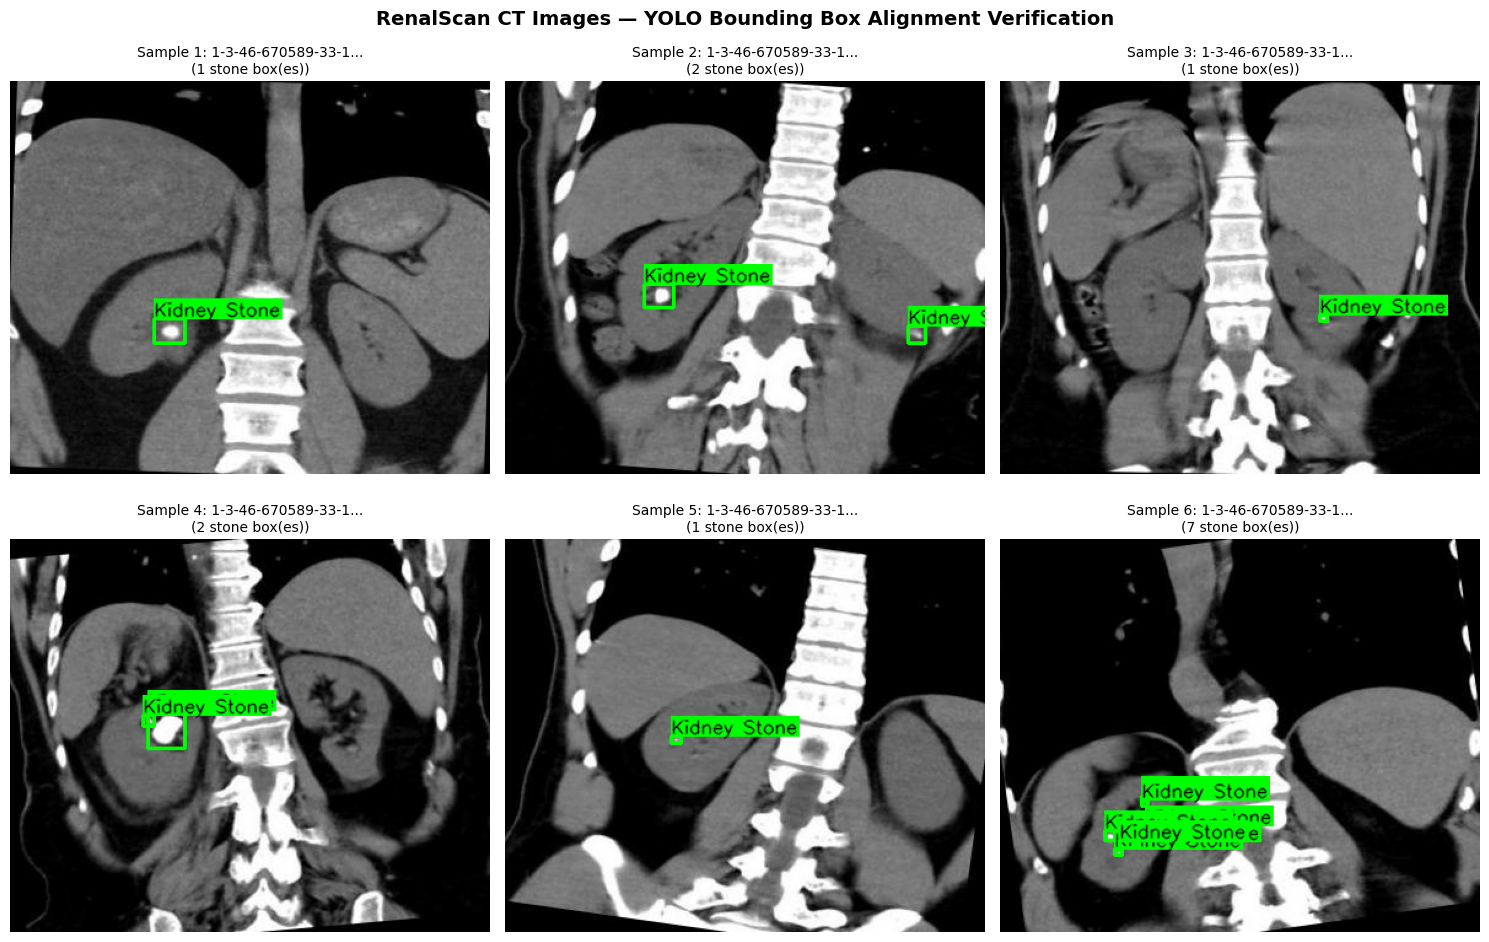

Saved sample visualization image to: C:\Users\akhil\Desktop\Renal Scan\notebooks\sample_bbox_visualization.png


In [5]:
# 4. Display 6 sample images with drawn YOLO bounding boxes
class_names = data_config.get('names', ['Kidney Stone'])
if isinstance(class_names, dict):
    class_names = list(class_names.values())

all_train_imgs = sorted(list(TRAIN_IMG_DIR.glob("*.jpg")))
# Pick 6 evenly spaced sample images
sample_indices = np.linspace(0, len(all_train_imgs) - 1, 6, dtype=int)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, img_idx in enumerate(sample_indices):
    img_path = all_train_imgs[img_idx]
    lbl_path = TRAIN_LBL_DIR / (img_path.stem + ".txt")
    
    # Read image with OpenCV and convert BGR -> RGB for Matplotlib
    bgr_img = cv2.imread(str(img_path))
    rgb_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
    
    # Parse YOLO format labels
    boxes = parse_yolo_label(lbl_path)
    
    # Overlay bounding box annotations
    annotated_img = draw_bounding_boxes(rgb_img, boxes, class_names)
    
    # Plot annotated image
    axes[idx].imshow(annotated_img)
    axes[idx].set_title(f"Sample {idx+1}: {img_path.name[:18]}...\n({len(boxes)} stone box(es))", fontsize=10)
    axes[idx].axis("off")

plt.suptitle("RenalScan CT Images — YOLO Bounding Box Alignment Verification", fontsize=14, fontweight='bold')
plt.tight_layout()
output_fig_path = Path("../notebooks/sample_bbox_visualization.png")
plt.savefig(output_fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved sample visualization image to: {output_fig_path.resolve()}")